<div style="background-color: #84bfef; padding: 20px; border-radius: 10px">

# Desafío #1 | Equipo 31 | EDA RRHH
</div>


## 1. Objetivo del análisis

Este EDA busca entender si el dataset de RRHH permite responder las preguntas del desafío, detectar problemas de calidad y preparar criterios para el análisis posterior y el dashboard.

El análisis contempla dos áreas:

- **Perfil y Desempeño Profesional:** perfil sociodemográfico y laboral de los empleados.
- **Absentismo y Bienestar Laboral:** magnitud, temporalidad y motivos del absentismo.

El EDA no limpia ni transforma definitivamente los datos. Solo identifica hallazgos, riesgos e incidencias que deberán tratarse en la fase de limpieza.


### 1.1 Preguntas de negocio, KPI y columnas

**Magnitud del absentismo**  
KPI / análisis: IDs con registros de ausencia y horas totales.  
Columnas: `ID`, `Absenteeism_hours`.

**Variación mensual del absentismo**  
KPI / análisis: mes pico por horas y por registros.  
Columnas: `Month_absence`, `Absenteeism_hours`, `ID`.

**Motivo principal de ausencia**  
KPI / análisis: motivo modal y motivos con más horas.  
Columnas: `Reason_absence`, `Absenteeism_hours`, `ID`.

**Continuidad operativa**  
KPI / análisis: carga laboral, hit target y horas de ausencia.  
Columnas: `Work_load_Average_day`, `Absenteeism_hours`, `Hit_target`.

**Perfil sociodemográfico/laboral**  
KPI / análisis: distribución por edad, educación, antigüedad y distancia.  
Columnas: `Age`, `Education`, `Service_time`, `Distance_Residence_Work`, `Son`, `Pet`.


## 2. Librerías


In [133]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## 3. Carga de datos

El dataset se lee desde el archivo CSV versionado en el repositorio local:

`Data/raw/raw_data.csv`

Se usa ruta local del proyecto, no la URL de GitHub, para que el notebook funcione dentro de cualquier clon de la rama.


In [134]:
ruta_actual = Path.cwd().resolve()

posibles_raices = [ruta_actual, *ruta_actual.parents]
project_root = next(
    (
        ruta
        for ruta in posibles_raices
        if (ruta / "Data" / "raw" / "raw_data.csv").exists()
    ),
    None
)

if project_root is None:
    raise FileNotFoundError(
        "No se encontró Data/raw/raw_data.csv. "
        "Ejecuta el notebook desde dentro del proyecto Equip_31 o revisa la ruta del archivo."
    )

raw_data_path = project_root / "Data" / "raw" / "raw_data.csv"
RRHH = pd.read_csv(raw_data_path)

print("Archivo cargado:", raw_data_path)
print("Dimensiones:", RRHH.shape)
RRHH.head()


Archivo cargado: /Users/fedeur/IT Academy/Simulador Empresarial/ProjecteData/Equip_31/Data/raw/raw_data.csv
Dimensiones: (740, 21)


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112


## 4. Vistazo inicial

Se revisa tamaño, columnas, tipos de datos y muestra inicial para entender cómo llega el dataset antes de analizarlo.


In [135]:
estructura_inicial = pd.DataFrame({
    "columna": RRHH.columns,
    "tipo_dato": RRHH.dtypes.astype(str).values,
    "nulos": RRHH.isna().sum().values,
    "vacios_texto": [
        RRHH[col].astype(str).str.strip().eq("").sum()
        for col in RRHH.columns
    ],
    "valores_unicos": RRHH.nunique().values
})

estructura_inicial


,columna,tipo_dato,nulos,vacios_texto,valores_unicos
0,ID,int64,0,0,36
1,Reason_absence,int64,0,0,28
2,Month_absence,int64,0,0,13
3,Day_week,int64,0,0,5
4,Seasons,int64,0,0,4
5,Transportation_expense,int64,0,0,24
6,Distance_Residence_Work,int64,0,0,25
7,Service_time,int64,0,0,18
8,Age,int64,0,0,22
9,Work_load_Average_day,str,0,0,38


In [136]:
RRHH.describe(include="all")


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740,...,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"222,196",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,18.017568,19.216216,6.324324,3.914865,2.544595,221.329730,29.631081,12.554054,36.450000,NaN,...,0.054054,1.291892,1.018919,0.567568,0.072973,0.745946,79.035135,172.114865,26.677027,6.924324
std,11.021247,8.433406,3.436287,1.421675,1.111831,66.952223,14.836788,4.384873,6.478772,NaN,...,0.226277,0.673238,1.098489,0.495749,0.260268,1.318258,12.883211,6.034995,4.285452,13.330998
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,NaN,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,9.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,NaN,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,NaN,...,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,NaN,...,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000


**Observación EDA:** `Work_load_Average_day` aparece como texto aunque representa una variable numérica. En esta fase se documenta el problema, pero la conversión definitiva corresponde a limpieza.


## 5. Unidad de análisis

El dataset contiene 740 filas y 36 IDs únicos. Esto indica que una fila no representa necesariamente un empleado único, sino un registro asociado a un empleado.

Como existen filas con `Absenteeism_hours = 0`, es más prudente hablar de **registro de seguimiento de RRHH** y no asumir que todas las filas son episodios reales de absentismo.<br> 
Cuando existe una medida disciplinaria `Absenteeism_hours = 0`.


In [137]:
unidad_analisis = pd.DataFrame({
    "Métrica": [
        "Total registros",
        "IDs únicos",
        "Media de registros por ID",
        "Máximo de registros en un ID",
        "Registros con Absenteeism_hours = 0"
    ],
    "Resultado": [
        len(RRHH),
        RRHH["ID"].nunique(),
        round(RRHH.groupby("ID").size().mean(), 2),
        RRHH.groupby("ID").size().max(),
        (RRHH["Absenteeism_hours"] == 0).sum()
    ]
})

unidad_analisis


,Métrica,Resultado
0,Total registros,740.00
1,IDs únicos,36.00
2,Media de registros por ID,20.56
3,Máximo de registros en un ID,113.00
4,Registros con Absenteeism_hours = 0,44.00


## 6. Calidad inicial de datos

Se revisan nulos, vacíos, IDs repetidos, duplicados exactos y valores especiales. En esta fase no se corrige nada: solo se identifican incidencias para limpieza.


In [138]:
columnas_rrhh = RRHH.columns.tolist()

duplicados_exactos_por_fila = (
    RRHH
    .groupby(columnas_rrhh, dropna=False)
    .size()
    .reset_index(name="times_repeated")
    .query("times_repeated > 1")
)

ids_con_duplicados_exactos = (
    duplicados_exactos_por_fila["ID"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

control_calidad_registros = pd.DataFrame({
    "Métrica": [
        "Total registros",
        "IDs únicos",
        "ID extras",
        "Duplicados exactos extra",
        "Filas involucradas en duplicados exactos",
        "Grupos exactos duplicados",
        "IDs con duplicados exactos"
    ],
    "Resultado": [
        len(RRHH),
        RRHH["ID"].nunique(),
        len(RRHH) - RRHH["ID"].nunique(),
        RRHH.duplicated(keep="first").sum(),
        RRHH.duplicated(keep=False).sum(),
        len(duplicados_exactos_por_fila),
        ids_con_duplicados_exactos.nunique()
    ],
    "Cómo se interpreta": [
        "Total de filas",
        "Empleados distintos",
        "Apariciones adicionales de IDs repetidos",
        "Filas repetidas completas sobrantes",
        "Originales + duplicadas",
        "Combinaciones de fila completa repetida",
        "IDs afectados por filas exactamente repetidas"
    ]
})

control_calidad_registros


,Métrica,Resultado,Cómo se interpreta
0,Total registros,740,Total de filas
1,IDs únicos,36,Empleados distintos
2,ID extras,704,Apariciones adicionales de IDs repetidos
3,Duplicados exactos extra,34,Filas repetidas completas sobrantes
4,Filas involucradas en duplicados exactos,60,Originales + duplicadas
5,Grupos exactos duplicados,26,Combinaciones de fila completa repetida
6,IDs con duplicados exactos,9,IDs afectados por filas exactamente repetidas


In [139]:
revision_nulos_vacios = pd.DataFrame({
    "columna": RRHH.columns,
    "nulos": RRHH.isna().sum().values,
    "vacios": [
        RRHH[col].astype(str).str.strip().eq("").sum()
        for col in RRHH.columns
    ]
})

revision_nulos_vacios["total_nulos_o_vacios"] = (
    revision_nulos_vacios["nulos"] + revision_nulos_vacios["vacios"]
)

revision_nulos_vacios


,columna,nulos,vacios,total_nulos_o_vacios
0,ID,0,0,0
1,Reason_absence,0,0,0
2,Month_absence,0,0,0
3,Day_week,0,0,0
4,Seasons,0,0,0
5,Transportation_expense,0,0,0
6,Distance_Residence_Work,0,0,0
7,Service_time,0,0,0
8,Age,0,0,0
9,Work_load_Average_day,0,0,0


In [140]:
valores_especiales = pd.DataFrame({
    "revisión": [
        "Month_absence igual a 0",
        "Reason_absence igual a 0",
        "Absenteeism_hours igual a 0"
    ],
    "registros": [
        (RRHH["Month_absence"] == 0).sum(),
        (RRHH["Reason_absence"] == 0).sum(),
        (RRHH["Absenteeism_hours"] == 0).sum()
    ]
})

valores_especiales


,revisión,registros
0,Month_absence igual a 0,3
1,Reason_absence igual a 0,43
2,Absenteeism_hours igual a 0,44


**Lectura EDA:** `Reason_absence = 0`, `Month_absence = 0` y `Absenteeism_hours = 0` no deben interpretarse sin diccionario de datos. Pueden ser códigos especiales, registros administrativos o valores no informados.


In [141]:
codigos_a_documentar = ["Reason_absence", "Day_week", "Seasons", "Education"]

resumen_codigos = []
for columna in codigos_a_documentar:
    resumen_codigos.append({
        "variable": columna,
        "valores_distintos": RRHH[columna].nunique(),
        "valores_observados": sorted(RRHH[columna].dropna().unique().tolist())
    })

pd.DataFrame(resumen_codigos)


,variable,valores_distintos,valores_observados
0,Reason_absence,28,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,Day_week,5,"[2, 3, 4, 5, 6]"
2,Seasons,4,"[1, 2, 3, 4]"
3,Education,4,"[1, 2, 3, 4]"


## 7. Diccionarios de códigos para interpretación

El dataset contiene variables codificadas. En EDA conviene crear tablas auxiliares de interpretación para entender qué significa cada código antes de presentar resultados de negocio.

Estas tablas no modifican el dataset original. Solo se usan para lectura exploratoria y para que tablas o gráficos puedan mostrar etiquetas comprensibles.


In [142]:
reason_absence_dict = pd.DataFrame({
    "Reason_absence": list(range(0, 29)),
    "Reason_absence_label": [
        "Code 0 - pendiente de validar con diccionario",
        "Certain infectious and parasitic diseases",
        "Neoplasms",
        "Diseases of the blood and blood-forming organs and immune disorders",
        "Endocrine, nutritional and metabolic diseases",
        "Mental and behavioural disorders",
        "Diseases of the nervous system",
        "Diseases of the eye and adnexa",
        "Diseases of the ear and mastoid process",
        "Diseases of the circulatory system",
        "Diseases of the respiratory system",
        "Diseases of the digestive system",
        "Diseases of the skin and subcutaneous tissue",
        "Diseases of the musculoskeletal system and connective tissue",
        "Diseases of the genitourinary system",
        "Pregnancy, childbirth and the puerperium",
        "Certain conditions originating in the perinatal period",
        "Congenital malformations and chromosomal abnormalities",
        "Symptoms, signs and abnormal clinical/laboratory findings",
        "Injury, poisoning and external causes",
        "External causes of morbidity and mortality",
        "Factors influencing health status and contact with health services",
        "Patient follow-up",
        "Medical consultation",
        "Blood donation",
        "Laboratory examination",
        "Unjustified absence",
        "Physiotherapy",
        "Dental consultation"
    ]
})

day_week_dict = pd.DataFrame({
    "Day_week": [2, 3, 4, 5, 6],
    "Day_week_label": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
})

seasons_dict = pd.DataFrame({
    "Seasons": [1, 2, 3, 4],
    "Season_label": ["Summer", "Autumn", "Winter", "Spring"]
})

education_dict = pd.DataFrame({
    "Education": [1, 2, 3, 4],
    "Education_label": ["High school", "Graduate", "Postgraduate", "Master and doctor"]
})

binary_dict = pd.DataFrame({
    "code": [0, 1],
    "label": ["No", "Yes"]
})

reason_absence_dict.head()


,Reason_absence,Reason_absence_label
0,0,Code 0 - pendiente de validar con diccionario
1,1,Certain infectious and parasitic diseases
2,2,Neoplasms
3,3,Diseases of the blood and blood-forming organs...
4,4,"Endocrine, nutritional and metabolic diseases"


In [143]:
RRHH_interpretado = (
    RRHH
    .merge(reason_absence_dict, on="Reason_absence", how="left")
    .merge(day_week_dict, on="Day_week", how="left")
    .merge(seasons_dict, on="Seasons", how="left")
    .merge(education_dict, on="Education", how="left")
)

RRHH_interpretado[[
    "ID",
    "Reason_absence",
    "Reason_absence_label",
    "Day_week",
    "Day_week_label",
    "Seasons",
    "Season_label",
    "Education",
    "Education_label"
]].head()


,ID,Reason_absence,Reason_absence_label,Day_week,Day_week_label,Seasons,Season_label,Education,Education_label
0,14,11,Diseases of the digestive system,2,Monday,4,Spring,1,High school
1,36,13,Diseases of the musculoskeletal system and con...,4,Wednesday,3,Winter,1,High school
2,9,6,Diseases of the nervous system,3,Tuesday,1,Summer,1,High school
3,28,9,Diseases of the circulatory system,3,Tuesday,1,Summer,1,High school
4,9,12,Diseases of the skin and subcutaneous tissue,3,Tuesday,2,Autumn,1,High school


**Lectura EDA:** el código `Reason_absence = 0` aparece en los datos, pero no está descrito en el diccionario original de motivos. Por tanto, debe mantenerse como valor pendiente de validación y no interpretarse como una causa concreta.


## 8. Consistencia de variables de perfil por ID

Algunas columnas parecen describir al empleado y no el registro: edad, educación, distancia al trabajo, peso, altura o índice de masa corporal. En EDA conviene comprobar si estas variables se mantienen constantes dentro de cada `ID`.

Si una variable de perfil cambia dentro del mismo `ID`, no se corrige aquí, pero se marca como incidencia para limpieza.


In [144]:
variables_perfil_estaticas = [
    "Age",
    "Education",
    "Service_time",
    "Distance_Residence_Work",
    "Transportation_expense",
    "Son",
    "Social_drinker",
    "Social_smoker",
    "Pet",
    "Weight",
    "Height",
    "Body_mass_index"
]

variacion_perfil_por_id = []

for columna in variables_perfil_estaticas:
    valores_distintos_por_id = RRHH.groupby("ID")[columna].nunique(dropna=False)

    variacion_perfil_por_id.append({
        "variable": columna,
        "ids_total": valores_distintos_por_id.shape[0],
        "ids_con_1_valor": (valores_distintos_por_id == 1).sum(),
        "ids_con_mas_de_1_valor": (valores_distintos_por_id > 1).sum(),
        "max_valores_distintos_en_un_id": valores_distintos_por_id.max(),
        "ids_que_varian": valores_distintos_por_id[valores_distintos_por_id > 1].index.tolist()
    })

variacion_perfil_por_id = pd.DataFrame(variacion_perfil_por_id)

variacion_perfil_por_id


,variable,ids_total,ids_con_1_valor,ids_con_mas_de_1_valor,max_valores_distintos_en_un_id,ids_que_varian
0,Age,36,35,1,2,[29]
1,Education,36,35,1,2,[29]
2,Service_time,36,35,1,2,[29]
3,Distance_Residence_Work,36,35,1,2,[29]
4,Transportation_expense,36,36,0,1,[]
5,Son,36,35,1,2,[29]
6,Social_drinker,36,35,1,2,[29]
7,Social_smoker,36,36,0,1,[]
8,Pet,36,36,0,1,[]
9,Weight,36,35,1,2,[29]


In [145]:
ids_con_perfil_variable = sorted(
    {
        id_empleado
        for ids in variacion_perfil_por_id["ids_que_varian"]
        for id_empleado in ids
    }
)

registros_perfil_variable = (
    RRHH[RRHH["ID"].isin(ids_con_perfil_variable)]
    .sort_values(["ID", "Month_absence", "Reason_absence", "Absenteeism_hours"])
)

print("IDs con cambios en variables de perfil:", ids_con_perfil_variable)
registros_perfil_variable


IDs con cambios en variables de perfil: [29]


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
555,29,28,2,6,2,225,15,15,41,"264,249",...,0,4,2,1,0,2,94,182,28,2
252,29,14,5,5,3,225,15,15,41,"237,656",...,0,4,2,1,0,2,94,182,28,8
441,29,19,5,4,3,225,15,15,41,"237,656",...,0,4,2,1,0,2,94,182,28,3
253,29,22,5,6,3,225,15,15,41,"237,656",...,0,4,2,1,0,2,94,182,28,8
698,29,0,9,2,4,225,26,9,28,"241,476",...,1,1,1,0,0,2,69,169,24,0


**Lectura EDA:** la mayoría de variables de perfil se mantienen constantes por empleado. Sin embargo, se detecta el `ID 29` con cambios en variables como edad, educación, distancia al trabajo, peso, altura y BMI. Esto puede indicar error de carga, reutilización de ID o mezcla de registros de personas distintas, y debe revisarse en limpieza.


## 9. Variables relevantes

Se separan variables candidatas para las dos áreas del desafío. Esta selección es exploratoria; la selección final debe confirmarse después de limpieza.


In [146]:
columnas_perfil_desempeno = [
    "ID", "Age", "Education", "Service_time", "Transportation_expense",
    "Distance_Residence_Work", "Hit_target", "Work_load_Average_day",
    "Disciplinary_failure", "Son", "Social_drinker", "Social_smoker",
    "Pet", "Weight", "Height", "Body_mass_index"
]

columnas_absentismo_bienestar = [
    "ID", "Reason_absence", "Month_absence", "Day_week", "Seasons",
    "Absenteeism_hours", "Age", "Service_time", "Distance_Residence_Work",
    "Transportation_expense", "Education", "Son", "Social_drinker",
    "Social_smoker", "Body_mass_index"
]

pd.DataFrame({
    "Área": ["Perfil y desempeño", "Absentismo y bienestar"],
    "Número de columnas": [len(columnas_perfil_desempeno), len(columnas_absentismo_bienestar)],
    "Columnas": [", ".join(columnas_perfil_desempeno), ", ".join(columnas_absentismo_bienestar)]
})


,Área,Número de columnas,Columnas
0,Perfil y desempeño,16,"ID, Age, Education, Service_time, Transportati..."
1,Absentismo y bienestar,15,"ID, Reason_absence, Month_absence, Day_week, S..."


**Nota sobre bienestar:** variables como `Social_drinker`, `Social_smoker`, `Body_mass_index` o `Son` no miden bienestar laboral directamente. En este EDA se tratan solo como variables asociadas o proxys.


## 10. Análisis univariado

Se revisan distribuciones de variables fundamentales para entender rangos, concentración de valores y posibles valores extremos.


In [147]:
variables_fundamentales = [
    "Age",
    "Service_time",
    "Distance_Residence_Work",
    "Transportation_expense",
    "Hit_target",
    "Body_mass_index",
    "Absenteeism_hours"
]

RRHH[variables_fundamentales].describe().round(2)


,Age,Service_time,Distance_Residence_Work,Transportation_expense,Hit_target,Body_mass_index,Absenteeism_hours
count,740.00,740.00,740.00,740.00,740.00,740.00,740.00
mean,36.45,12.55,29.63,221.33,94.59,26.68,6.92
std,6.48,4.38,14.84,66.95,3.78,4.29,13.33
min,27.00,1.00,5.00,118.00,81.00,19.00,0.00
25%,31.00,9.00,16.00,179.00,93.00,24.00,2.00
50%,37.00,13.00,26.00,225.00,95.00,25.00,3.00
75%,40.00,16.00,50.00,260.00,97.00,31.00,8.00
max,58.00,29.00,52.00,388.00,100.00,38.00,120.00


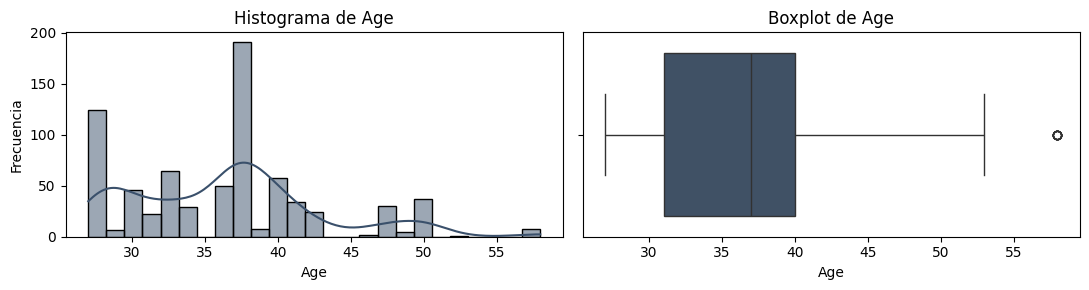

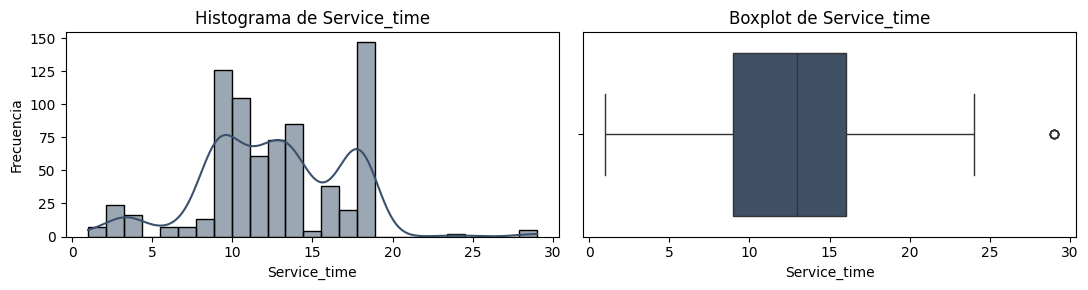

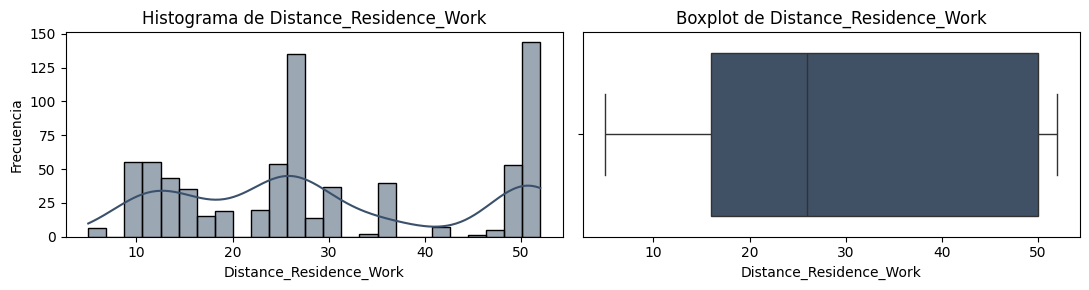

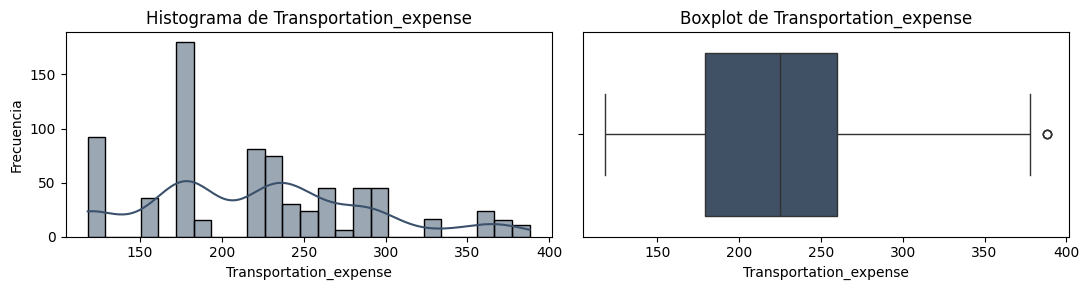

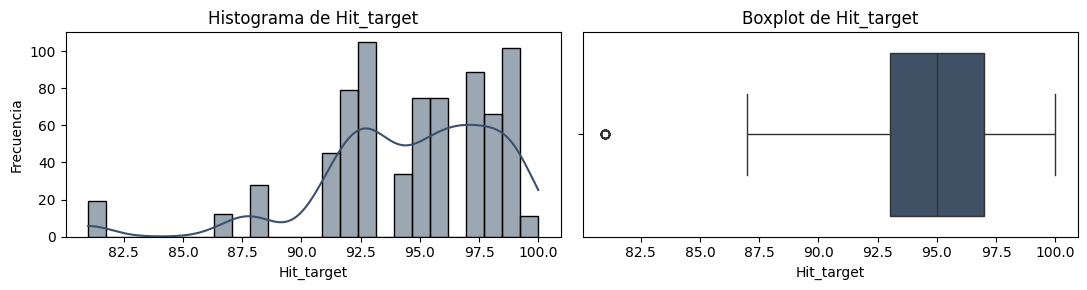

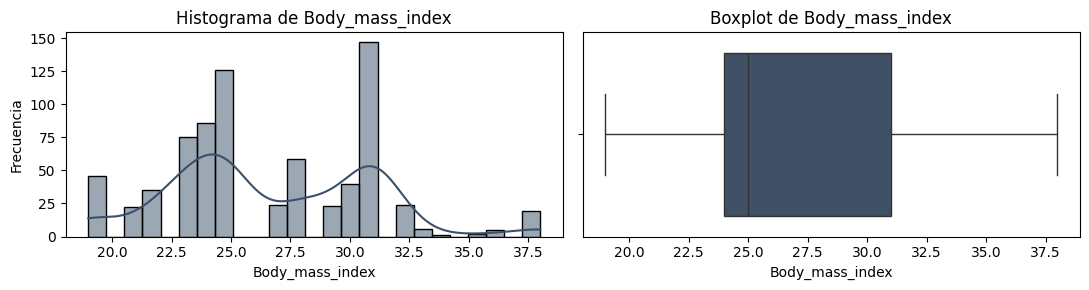

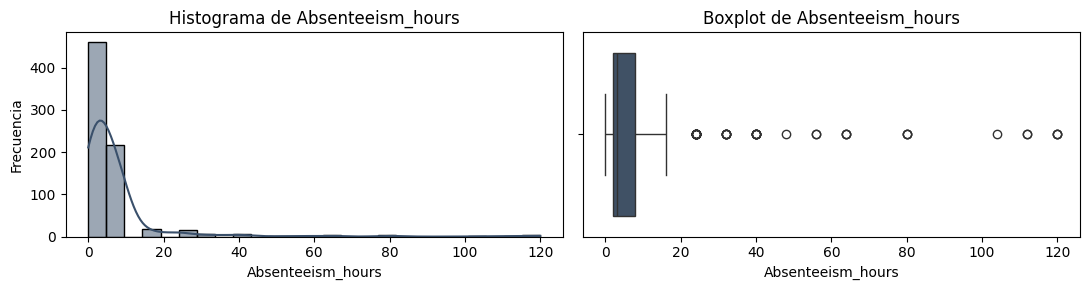

In [148]:
color_principal = "#3A506B"

for variable in variables_fundamentales:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3))

    sns.histplot(data=RRHH, x=variable, bins=25, kde=True, color=color_principal, ax=axes[0])
    axes[0].set_title(f"Histograma de {variable}")
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel("Frecuencia")

    sns.boxplot(data=RRHH, x=variable, color=color_principal, ax=axes[1])
    axes[1].set_title(f"Boxplot de {variable}")
    axes[1].set_xlabel(variable)

    plt.tight_layout()
    plt.show()


## 11. Análisis bivariado y relaciones clave

Se exploran relaciones directamente conectadas con las preguntas de negocio: absentismo por mes, motivo, día de la semana y perfil del empleado.


In [149]:
absentismo_por_mes = (
    RRHH.groupby("Month_absence")
    .agg(
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean")
    )
    .sort_index()
    .round(2)
)

absentismo_por_mes


,registros,empleados_unicos,horas_totales,horas_media
Month_absence,,,,
0,3,3,0,0.00
1,50,13,222,4.44
2,72,19,294,4.08
3,87,22,765,8.79
4,53,21,482,9.09
5,64,24,400,6.25
6,54,19,411,7.61
7,67,23,734,10.96
8,54,21,288,5.33


In [150]:
absentismo_por_motivo = (
    RRHH.groupby("Reason_absence")
    .agg(
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean")
    )
    .sort_values("horas_totales", ascending=False)
    .round(2)
)

absentismo_por_motivo.head(10)


,registros,empleados_unicos,horas_totales,horas_media
Reason_absence,,,,
13,55,18,842,15.31
19,40,17,729,18.23
23,149,24,424,2.85
28,112,17,335,2.99
11,26,14,297,11.42
22,38,12,293,7.71
10,25,13,276,11.04
26,33,11,240,7.27
18,21,12,217,10.33


In [151]:
absentismo_por_dia = (
    RRHH.groupby("Day_week")
    .agg(
        registros=("ID", "count"),
        empleados_unicos=("ID", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_media=("Absenteeism_hours", "mean")
    )
    .sort_index()
    .round(2)
)

absentismo_por_dia


,registros,empleados_unicos,horas_totales,horas_media
Day_week,,,,
2,161,30,1489,9.25
3,154,28,1229,7.98
4,156,29,1115,7.15
5,125,29,553,4.42
6,144,26,738,5.12


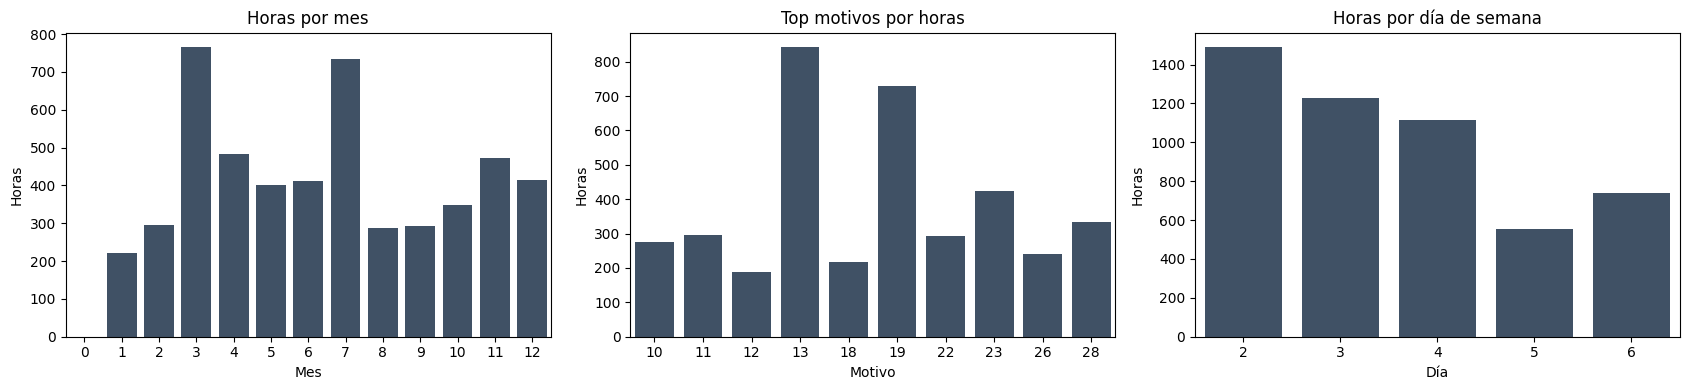

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sns.barplot(data=absentismo_por_mes.reset_index(), x="Month_absence", y="horas_totales", color=color_principal, ax=axes[0])
axes[0].set_title("Horas por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Horas")

top_motivos = absentismo_por_motivo.head(10).reset_index()
sns.barplot(data=top_motivos, x="Reason_absence", y="horas_totales", color=color_principal, ax=axes[1])
axes[1].set_title("Top motivos por horas")
axes[1].set_xlabel("Motivo")
axes[1].set_ylabel("Horas")

sns.barplot(data=absentismo_por_dia.reset_index(), x="Day_week", y="horas_totales", color=color_principal, ax=axes[2])
axes[2].set_title("Horas por día de semana")
axes[2].set_xlabel("Día")
axes[2].set_ylabel("Horas")

plt.tight_layout()
plt.show()


In [153]:
perfil_por_empleado = (
    RRHH.groupby("ID")
    .agg(
        registros=("ID", "count"),
        horas_absentismo_totales=("Absenteeism_hours", "sum"),
        horas_absentismo_media=("Absenteeism_hours", "mean"),
        edad=("Age", "first"),
        antiguedad=("Service_time", "first"),
        distancia_trabajo=("Distance_Residence_Work", "first"),
        educacion=("Education", "first"),
        hit_target_medio=("Hit_target", "mean")
    )
    .round(2)
    .reset_index()
)

perfil_por_empleado.sort_values("horas_absentismo_totales", ascending=False).head(10)


,ID,registros,horas_absentismo_totales,horas_absentismo_media,edad,antiguedad,distancia_trabajo,educacion,hit_target_medio
2,3,113,482,4.27,38,18,51,1,95.07
13,14,29,476,16.41,34,14,12,1,95.69
10,11,40,450,11.25,33,13,36,1,93.85
27,28,76,347,4.57,28,9,26,1,94.95
33,34,55,344,6.25,37,10,10,1,94.62
35,36,34,311,9.15,50,18,13,1,94.32
19,20,42,306,7.29,36,11,50,1,94.57
8,9,8,262,32.75,58,16,14,1,95.88
23,24,30,254,8.47,41,16,25,1,93.83
14,15,37,253,6.84,40,12,31,1,92.59


**Lectura EDA:** el análisis por empleado permite diferenciar empleados con muchos registros de empleados con muchas horas acumuladas. Esto es clave para no confundir repetición de `ID` con duplicidad.


## 12. Investigación de repetición por ID

Esta sección justifica por qué un mismo `ID` puede aparecer muchas veces. Si cambian meses, días, motivos u horas, las filas pueden representar situaciones distintas.


In [154]:
resumen_por_id = (
    RRHH
    .groupby("ID")
    .agg(
        total_filas=("ID", "count"),
        meses_distintos=("Month_absence", "nunique"),
        dias_distintos=("Day_week", "nunique"),
        motivos_distintos=("Reason_absence", "nunique"),
        estaciones_distintas=("Seasons", "nunique"),
        horas_totales=("Absenteeism_hours", "sum"),
        horas_distintas=("Absenteeism_hours", "nunique")
    )
    .sort_values("total_filas", ascending=False)
)

resumen_por_id.head(10)


,total_filas,meses_distintos,dias_distintos,motivos_distintos,estaciones_distintas,horas_totales,horas_distintas
ID,,,,,,,
3,113,12,5,14,4,482,9
28,76,11,5,16,4,347,9
34,55,12,5,14,4,344,10
22,46,11,5,9,4,253,8
20,42,11,5,11,4,306,8
11,40,11,5,11,4,450,10
15,37,12,5,9,4,253,9
36,34,10,5,9,4,311,9
24,30,10,5,11,4,254,9


In [155]:
id_mas_repetido = resumen_por_id.index[0]

registros_id_mas_repetido = (
    RRHH[RRHH["ID"] == id_mas_repetido]
    .sort_values(["Month_absence", "Day_week", "Reason_absence", "Absenteeism_hours"])
)

print(f"ID con más registros: {id_mas_repetido}")
registros_id_mas_repetido


ID con más registros: 3


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
416,3,27,1,4,2,179,51,18,38,"313,532",...,0,1,0,1,0,0,89,170,31,3
665,3,28,1,4,2,179,51,18,38,"330,061",...,0,1,0,1,0,0,89,170,31,1
417,3,27,1,5,2,179,51,18,38,"313,532",...,0,1,0,1,0,0,89,170,31,3
551,3,27,1,6,2,179,51,18,38,"313,532",...,0,1,0,1,0,0,89,170,31,2
666,3,28,1,6,2,179,51,18,38,"330,061",...,0,1,0,1,0,0,89,170,31,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,3,28,12,2,2,179,51,18,38,"236,629",...,0,1,0,1,0,0,89,170,31,3
27,3,13,12,3,4,179,51,18,38,"280,549",...,0,1,0,1,0,0,89,170,31,32
660,3,28,12,5,4,179,51,18,38,"236,629",...,0,1,0,1,0,0,89,170,31,1
661,3,28,12,6,4,179,51,18,38,"236,629",...,0,1,0,1,0,0,89,170,31,1


## 13. Criterios para limpieza

Estos puntos no se resuelven en el EDA, pero sí afectan la interpretación y deben tratarse antes del dashboard final.


In [156]:
incidencias_limpieza = pd.DataFrame({
    "Incidencia": [
        "Duplicados exactos",
        "Work_load_Average_day como texto",
        "Month_absence = 0",
        "Reason_absence = 0",
        "Absenteeism_hours = 0",
        "Códigos sin diccionario",
        "Variables de perfil que cambian dentro de un mismo ID",
        "Unidad de análisis mixta"
    ],
    "Criterio propuesto": [
        "Revisar si se eliminan las filas repetidas completas sobrantes",
        "Convertir a numérico en limpieza, no en EDA",
        "Investigar si es código especial o dato no informado",
        "No interpretar sin diccionario de motivos",
        "Revisar si representa ausencia cero, registro administrativo o código especial",
        "Documentar equivalencias de Reason_absence, Day_week, Seasons y Education",
        "Revisar el ID 29 porque cambian edad, educación, distancia, peso, altura y BMI",
        "Separar análisis por registro y por empleado"
    ]
})

incidencias_limpieza


,Incidencia,Criterio propuesto
0,Duplicados exactos,Revisar si se eliminan las filas repetidas com...
1,Work_load_Average_day como texto,"Convertir a numérico en limpieza, no en EDA"
2,Month_absence = 0,Investigar si es código especial o dato no inf...
3,Reason_absence = 0,No interpretar sin diccionario de motivos
4,Absenteeism_hours = 0,"Revisar si representa ausencia cero, registro ..."
5,Códigos sin diccionario,"Documentar equivalencias de Reason_absence, Da..."
6,Variables de perfil que cambian dentro de un m...,"Revisar el ID 29 porque cambian edad, educació..."
7,Unidad de análisis mixta,Separar análisis por registro y por empleado


## 14. Hallazgos y conclusión final

- El dataset tiene 740 registros y 36 IDs únicos.
- La unidad de análisis parece ser un registro de seguimiento de RRHH asociado a un empleado, no un empleado único.
- No hay nulos ni vacíos detectados, pero sí valores especiales que requieren diccionario.
- Las tablas auxiliares de códigos permiten interpretar variables como motivo de ausencia, día de semana, estación y educación sin modificar el dataset original.
- Hay 34 duplicados exactos extra, 60 filas involucradas en duplicados exactos, 26 grupos de filas repetidas y 9 IDs afectados por duplicados exactos.
- La repetición de `ID` no implica automáticamente duplicidad: muchos registros cambian por mes, día, motivo u horas.
- La mayoría de variables de perfil se mantienen constantes por empleado, pero el `ID 29` presenta cambios en variables como edad, educación, distancia, peso, altura y BMI.
- `Work_load_Average_day` debe tratarse en limpieza porque está almacenada como texto.
- Para el dashboard, conviene separar análisis por registro, para temporalidad y motivos, y análisis por empleado, para perfil/desempeño.
